In [1]:
!pip install -U scikit-fuzzy xgboost
!apt-get install -y graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 18.1 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.0.3
    Uninstalling xgboost-2.0.3:
      Successfully uninstalled xgboost-2.0.3



graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm import tqdm
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import xgboost as xgb
from IPython.display import Image

# --- Configuration ---
IMG_SIZE = 224
N_CLUSTERS = 3
DATA_PATH = '/kaggle/input/acute-lymphoblastic-leukemia/dataset'
SEG_OUTPUT_DIR = '/kaggle/working/segmented_images/'

# Create directories to save segmented images
os.makedirs(os.path.join(SEG_OUTPUT_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(SEG_OUTPUT_DIR, 'test'), exist_ok=True)

print(f"Segmented images will be saved in: {SEG_OUTPUT_DIR}")

2025-10-02 14:02:00.403743: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759413720.760474      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759413720.866926      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Segmented images will be saved in: /kaggle/working/segmented_images/


In [3]:
def load_data(path):
    filepaths = []
    labels = []
    malignant_folders = {'Early Pre-B', 'Pre-B', 'Pro-B'}
    
    for dir_name in os.listdir(path):
        dir_path = os.path.join(path, dir_name)
        if not os.path.isdir(dir_path):
            continue
            
        label = -1
        if dir_name == 'Benign':
            label = 0
        elif dir_name in malignant_folders:
            label = 1
        
        if label != -1:
            for filename in os.listdir(dir_path):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                    filepaths.append(os.path.join(dir_path, filename))
                    labels.append(label)
                    
    return filepaths, labels

filepaths, labels = load_data(DATA_PATH)
X = np.array(filepaths)
y = np.array(labels)

X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data: {len(X_train_paths)} samples")
print(f"Testing data: {len(X_test_paths)} samples")

Training data: 2593 samples
Testing data: 649 samples


In [4]:
def segment_image_fcm(image_path, img_size, n_clusters):
    """Performs Fuzzy C-Means segmentation on a single image."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    
    pixel_values = img.reshape((-1, 3)).astype(np.float32)
    
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        pixel_values.T, n_clusters, 2, error=0.005, maxiter=1000, init=None
    )
    
    cluster_membership = np.argmax(u, axis=0)
    
    counts = np.bincount(cluster_membership)
    target_cluster = np.argmin(counts[np.nonzero(counts)]) if len(counts) > 1 else 0
    
    segmented_pixels = np.zeros_like(pixel_values, dtype=np.uint8)
    segmented_pixels[cluster_membership == target_cluster] = pixel_values[cluster_membership == target_cluster].astype(np.uint8)
    
    return segmented_pixels.reshape(img.shape)

def visualize_segmentation_pipeline(image_path, img_size, n_clusters):
    """Visualizes the simplified 3-stage segmentation process in high resolution."""
    # 1. Load Original Image
    original_img = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), (img_size, img_size))

    # 2. Get Predicted Mask from FCM
    predicted_segmented_img = segment_image_fcm(image_path, img_size, n_clusters)
    
    # 3. Create Overlay
    gray_mask = cv2.cvtColor(predicted_segmented_img, cv2.COLOR_RGB2GRAY)
    _, binary_mask = cv2.threshold(gray_mask, 1, 255, cv2.THRESH_BINARY)
    overlay = original_img.copy()
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)

    # 4. Plotting (Increased figsize and dpi for higher resolution)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
    fig.suptitle("Segmentation Pipeline Visualization (High-Res)", fontsize=16)

    axes[0].imshow(original_img)
    axes[0].set_title('1. Original Image')
    axes[0].axis('off')

    axes[1].imshow(predicted_segmented_img)
    axes[1].set_title('2. Predicted Mask (FCM)')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('3. Overlay on Original')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

--- Visualizing Simplified Segmentation Pipeline (High-Res) ---


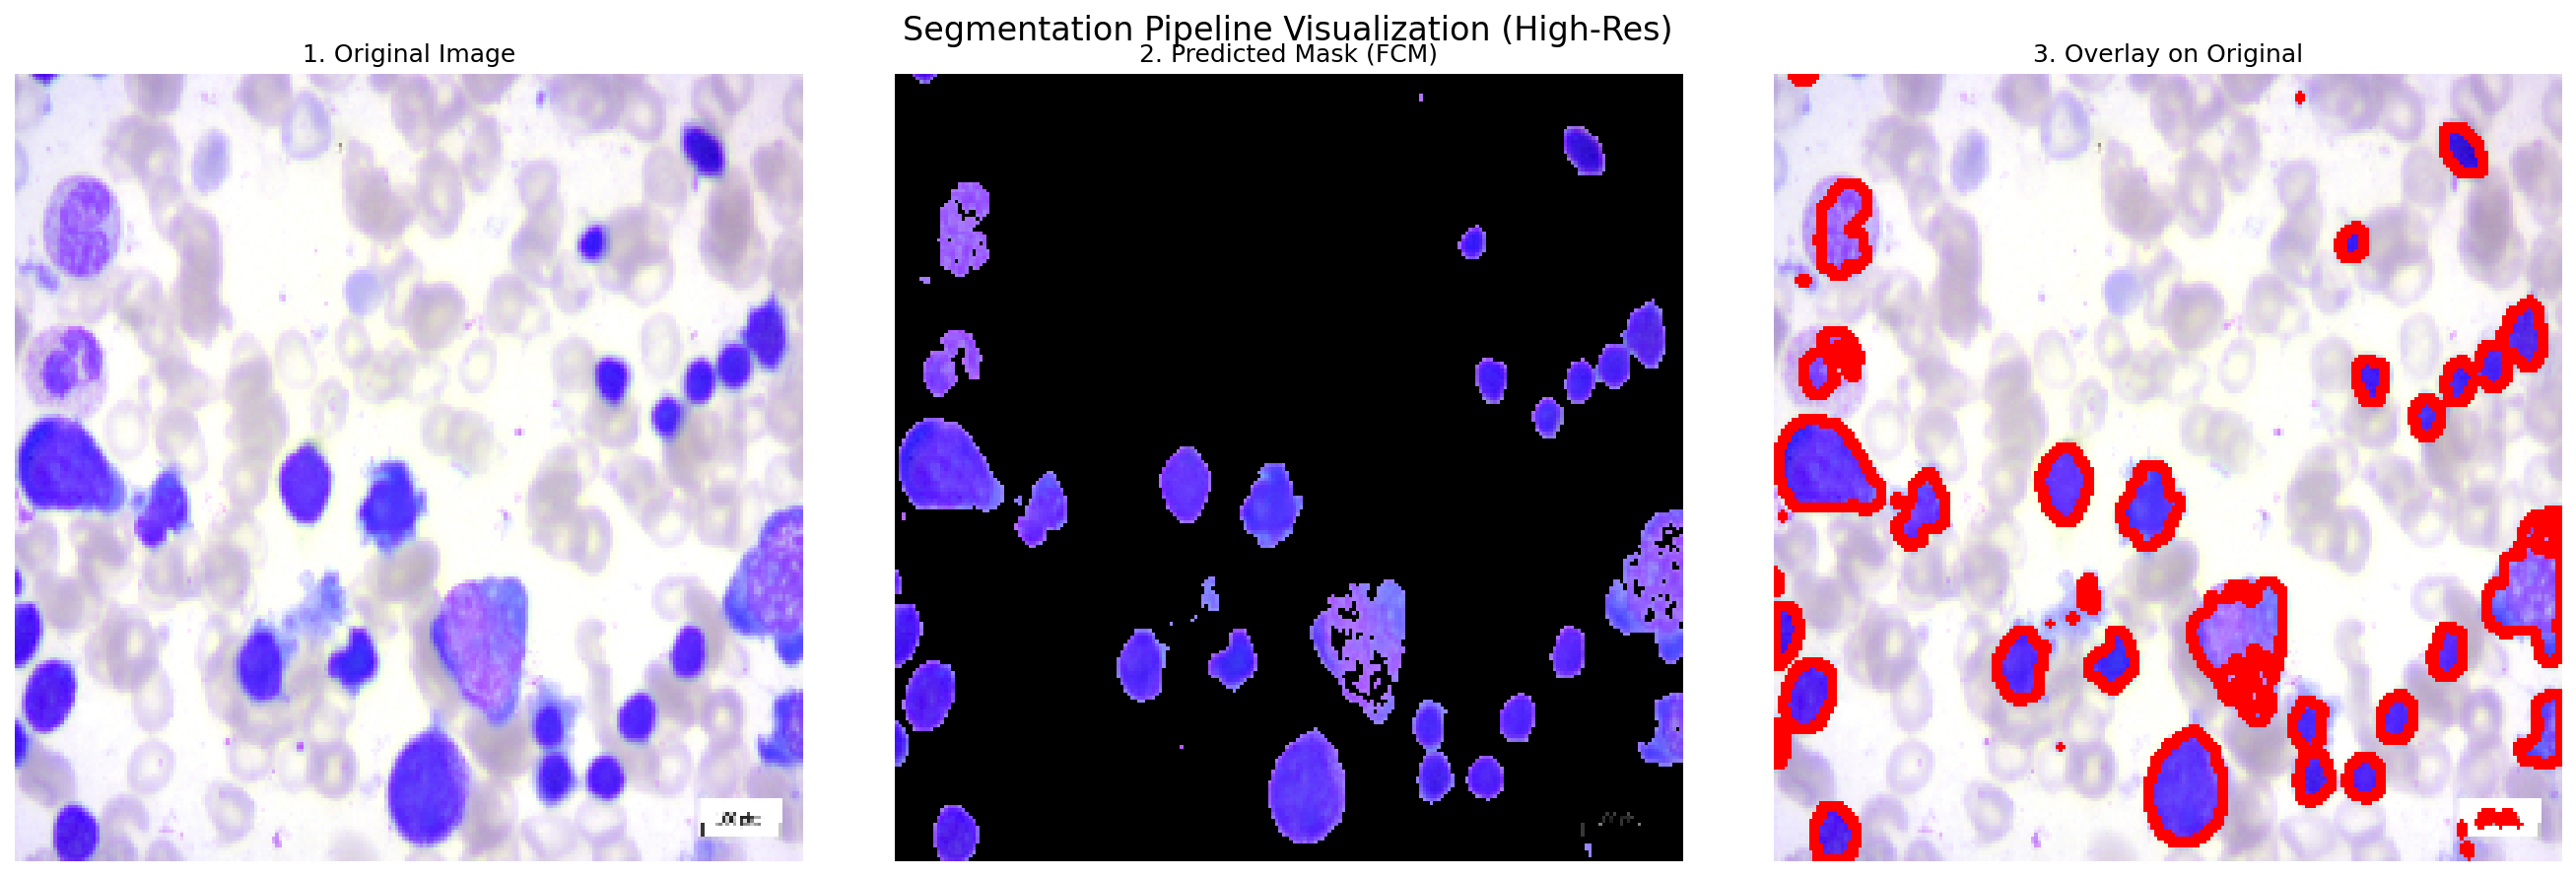

--- Displaying Segmentation Pipeline for 5 Random Sample Images ---

--- Sample Image 1 ---


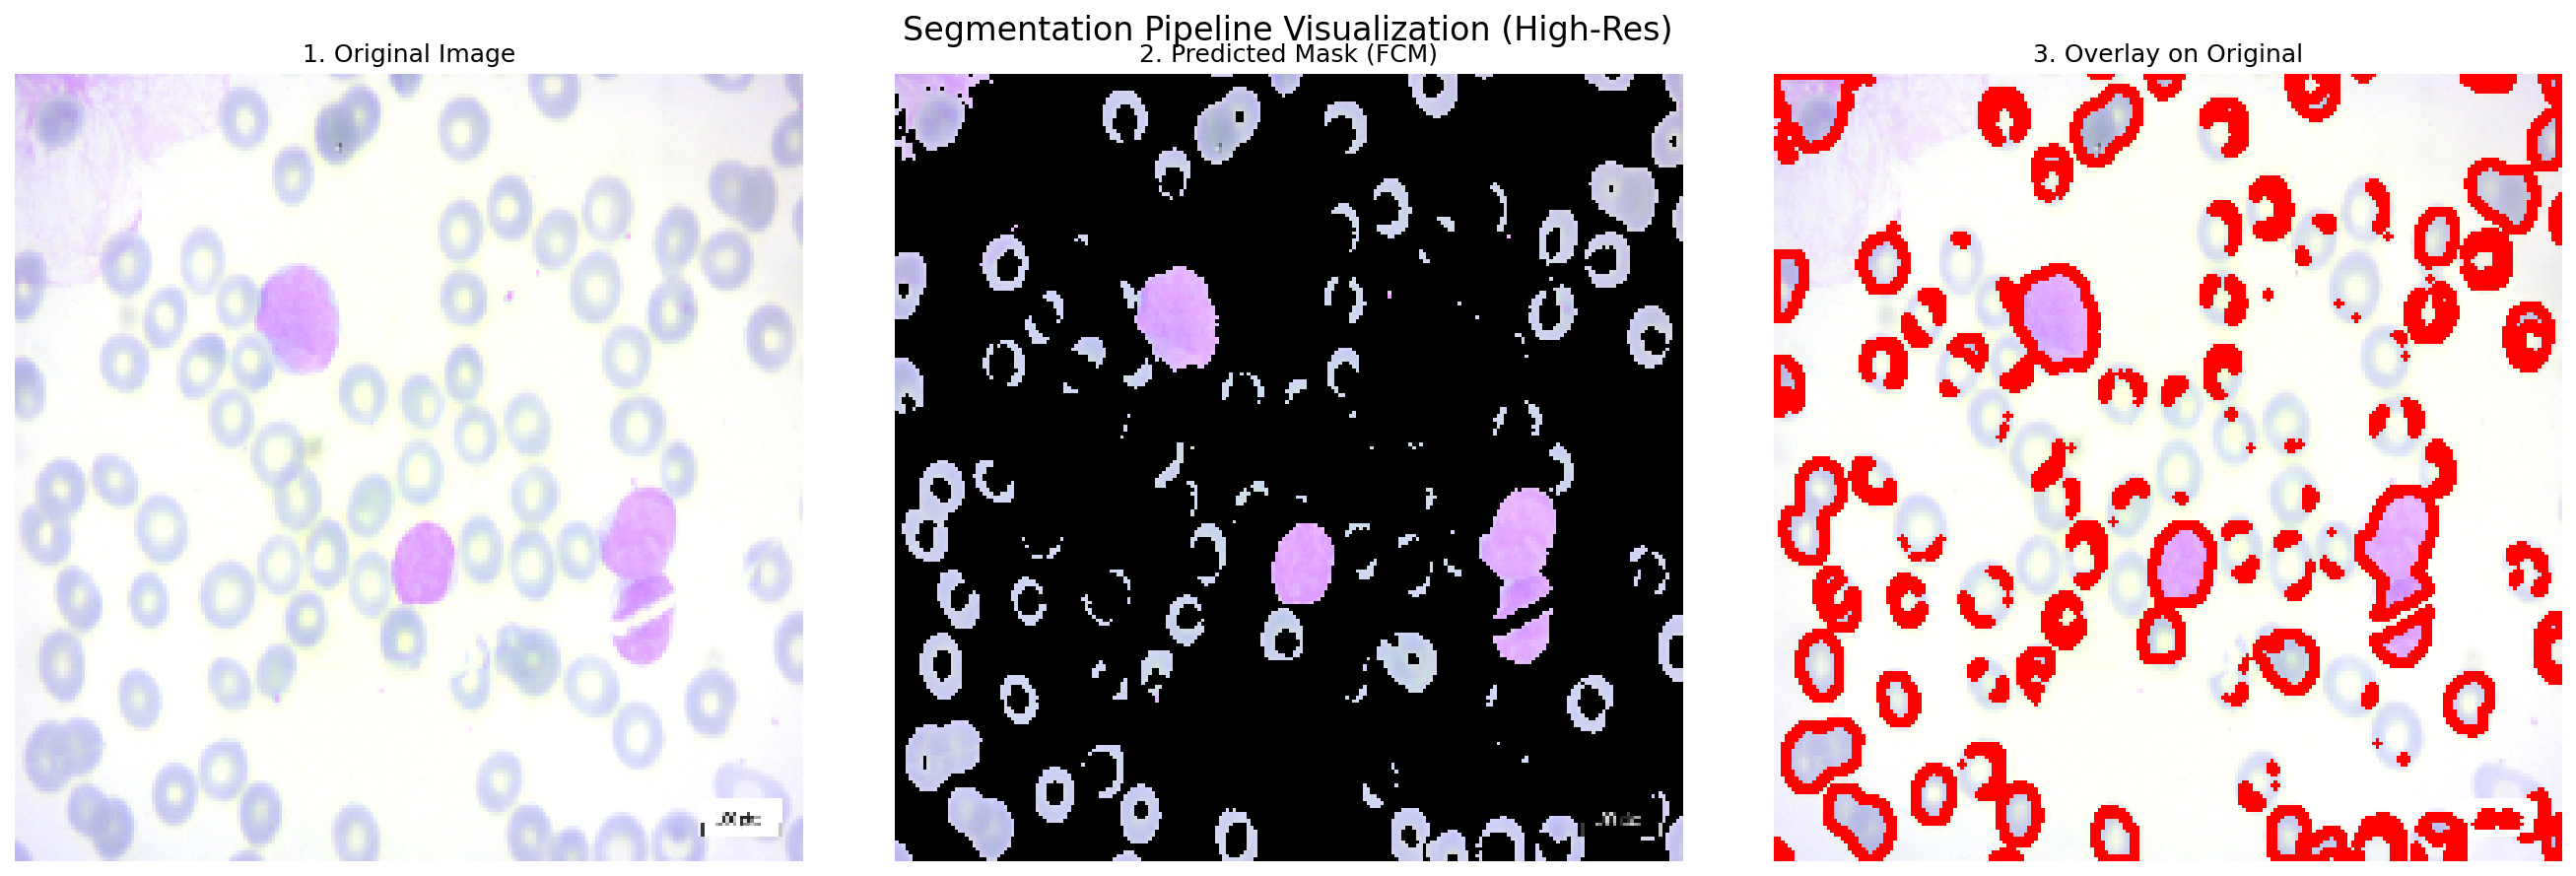


--- Sample Image 2 ---


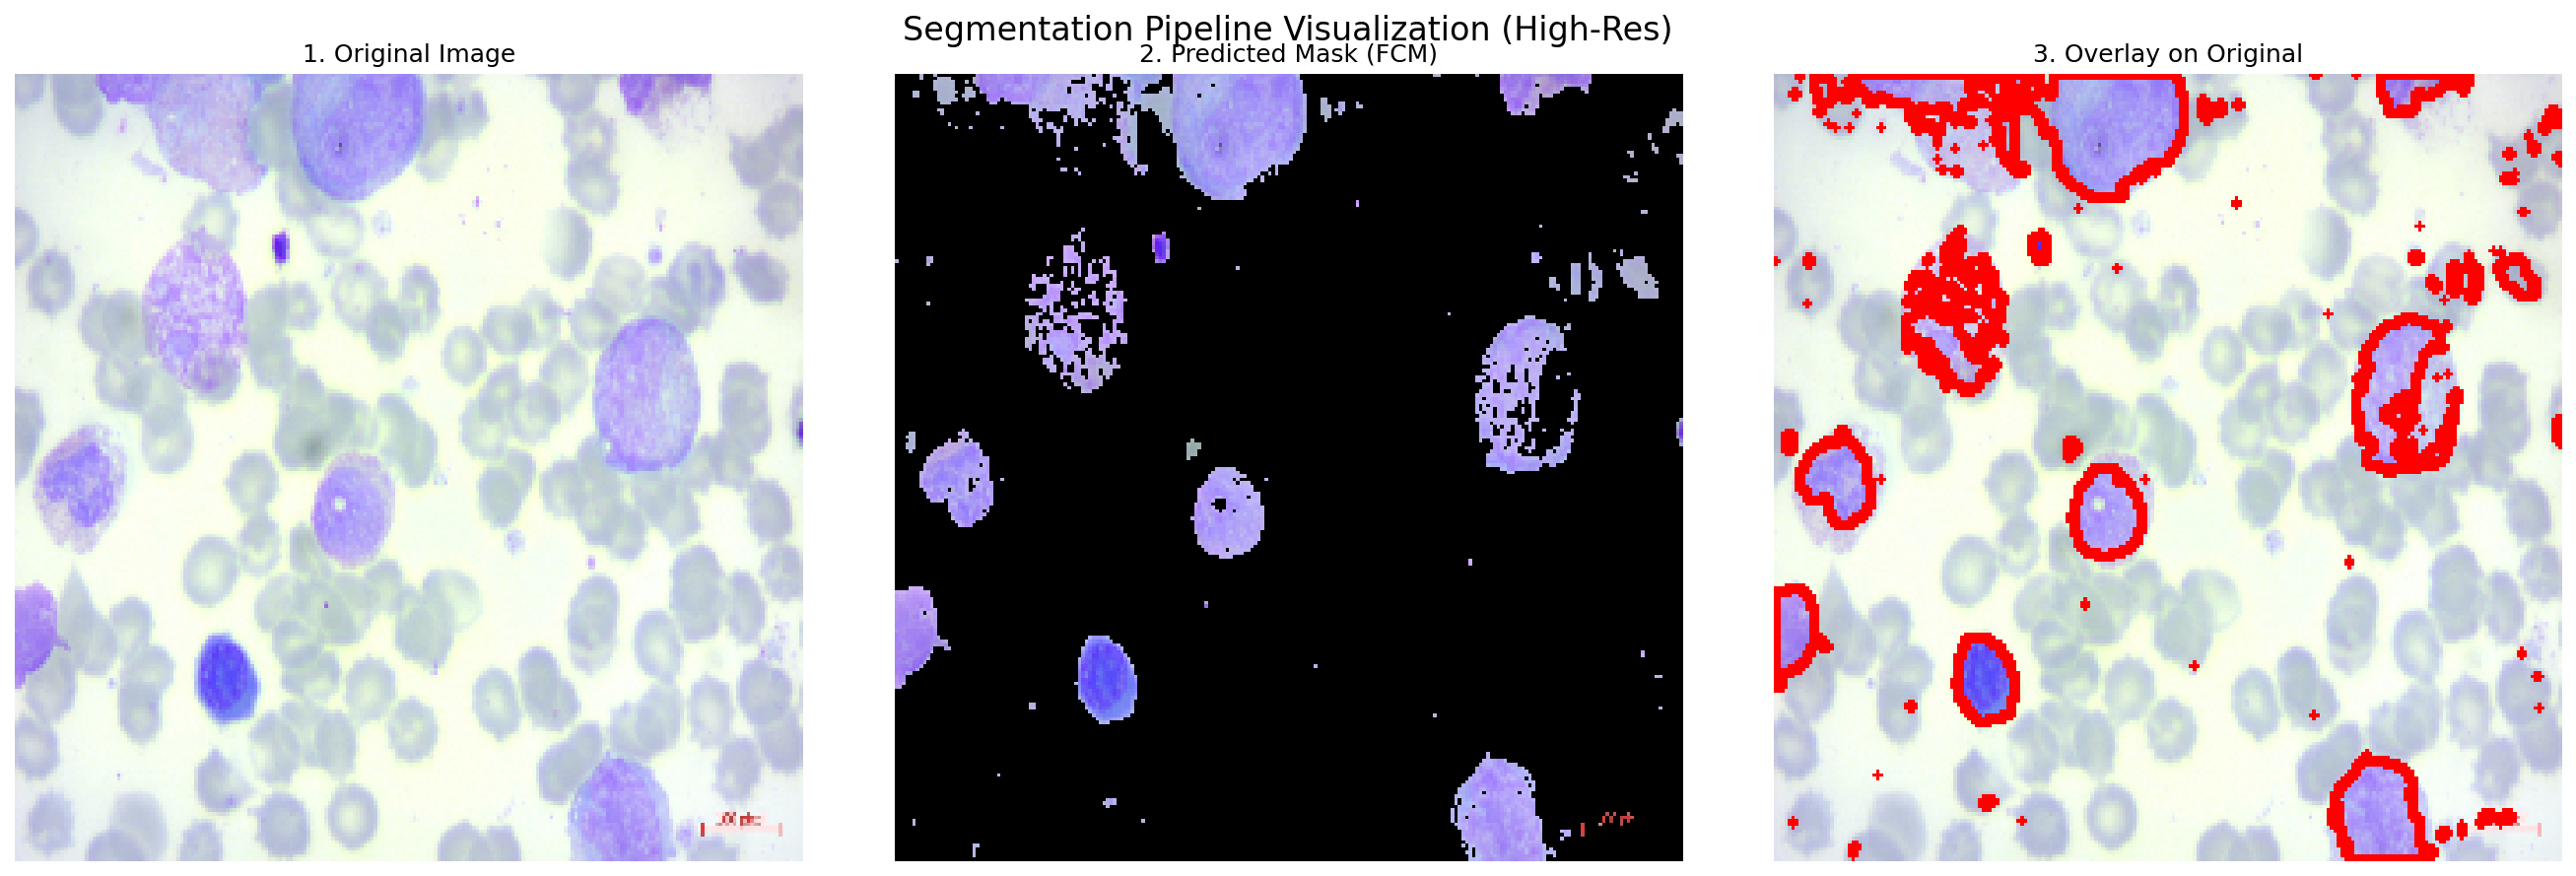


--- Sample Image 3 ---


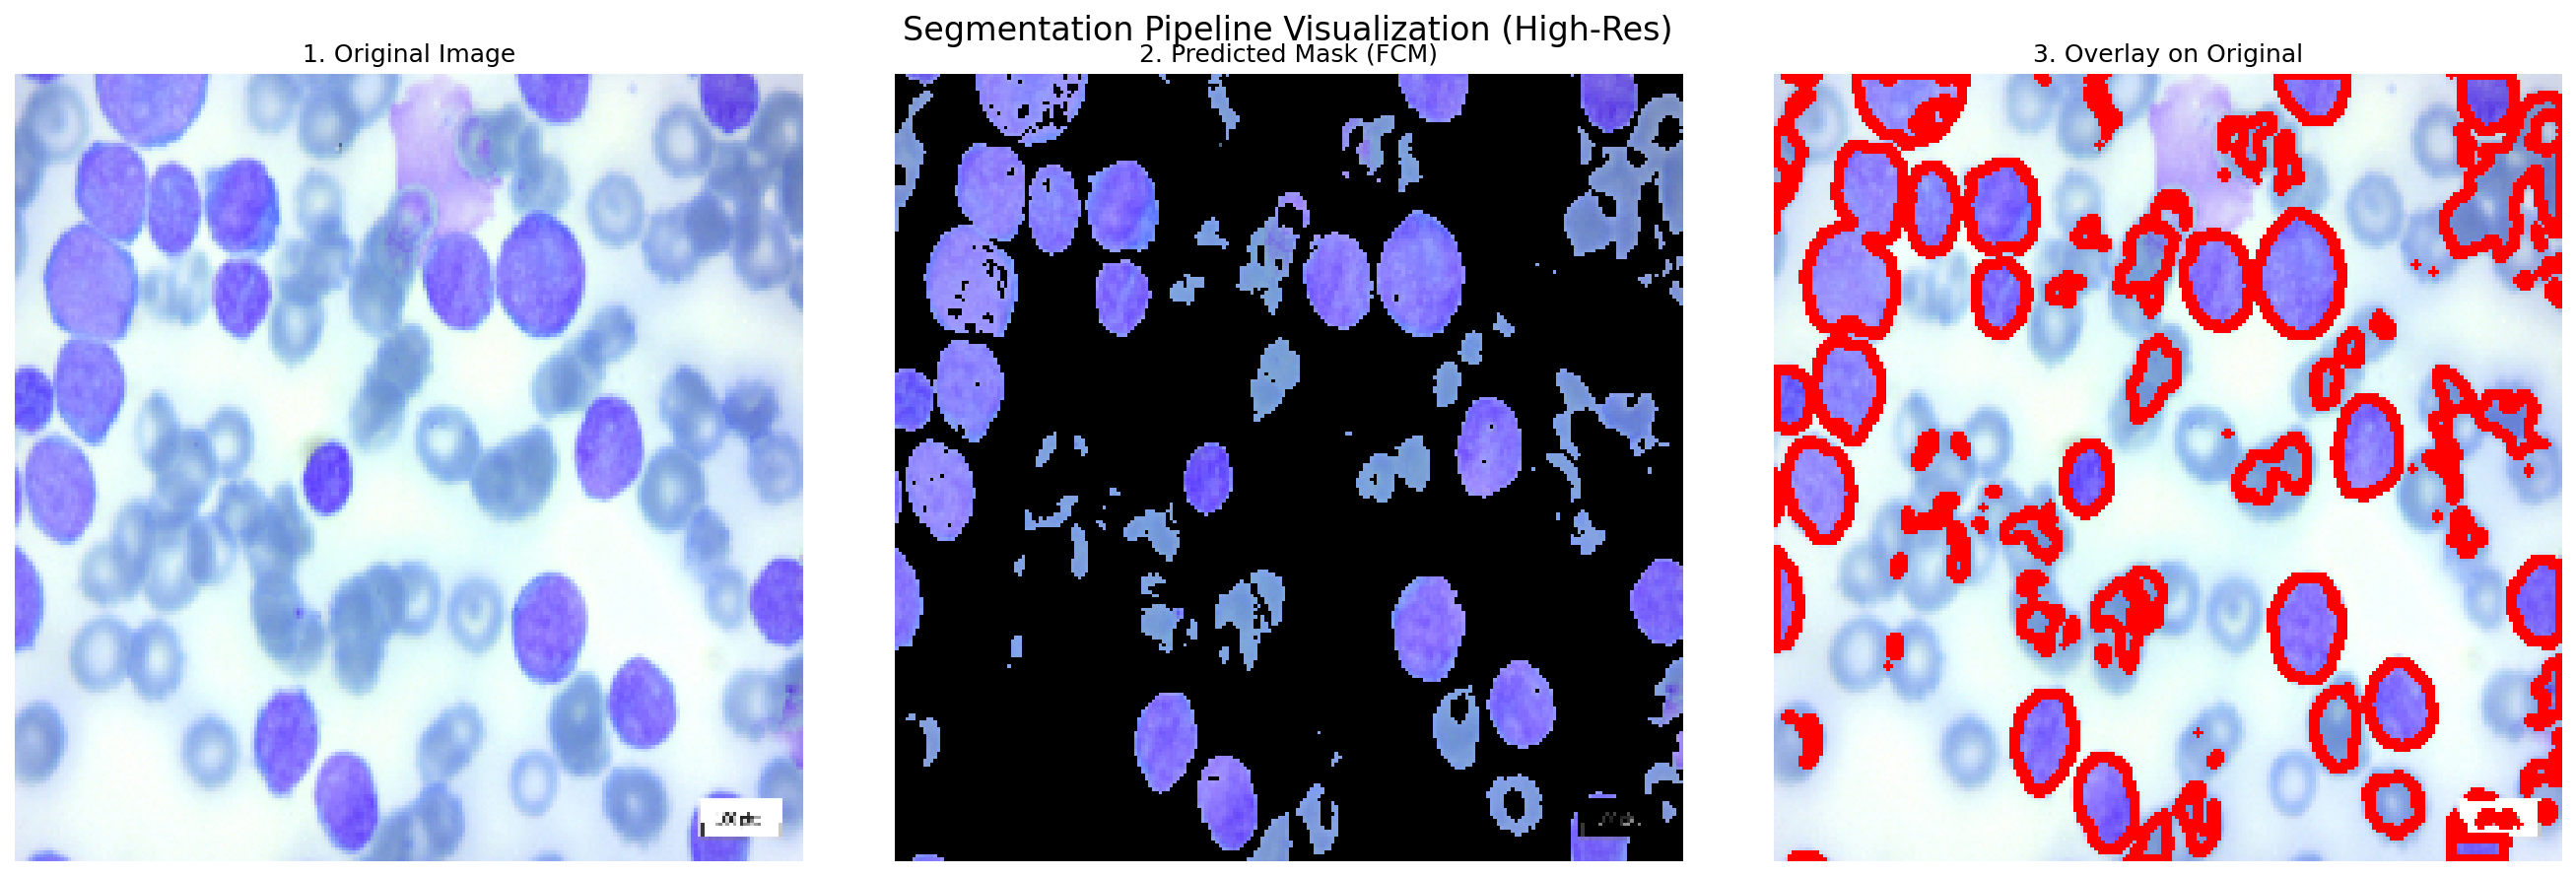


--- Sample Image 4 ---


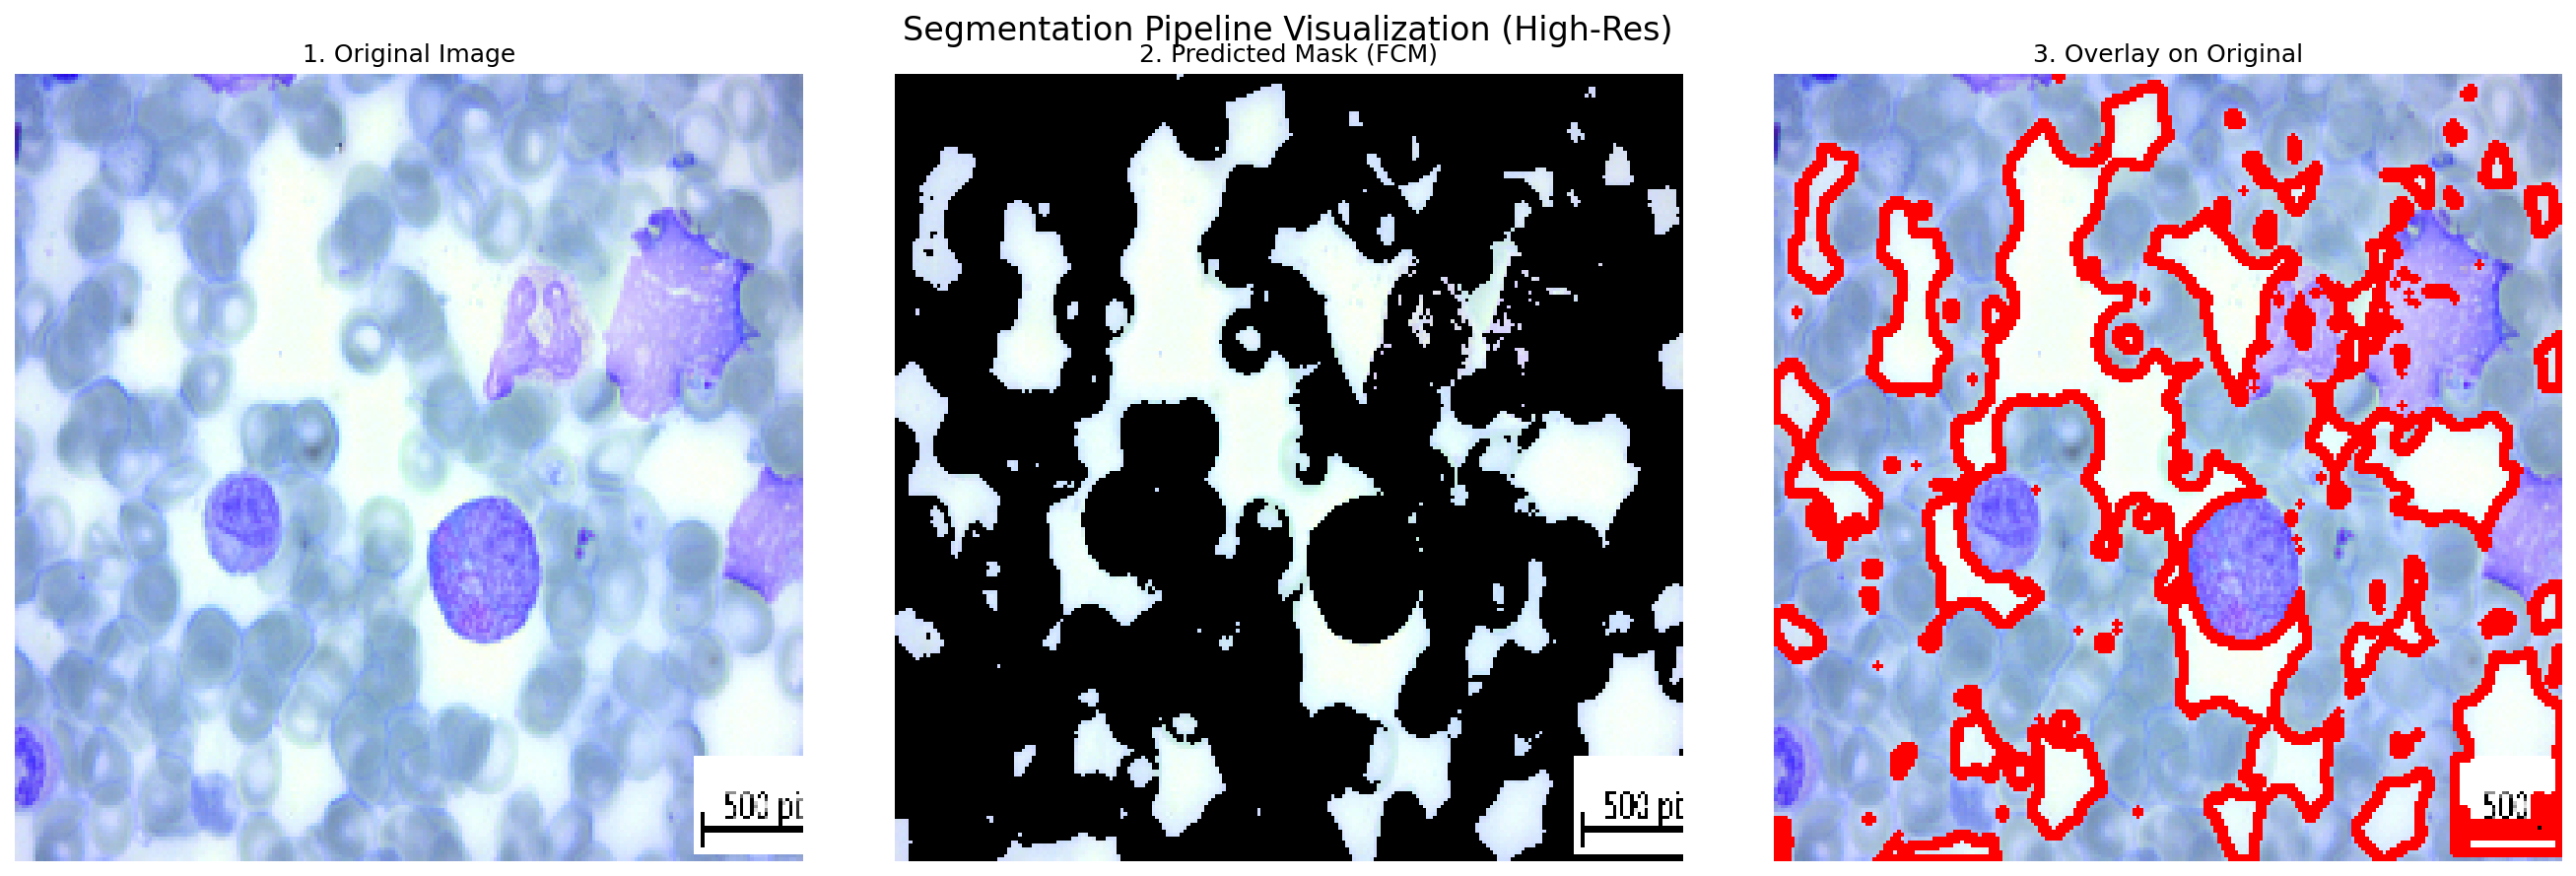


--- Sample Image 5 ---


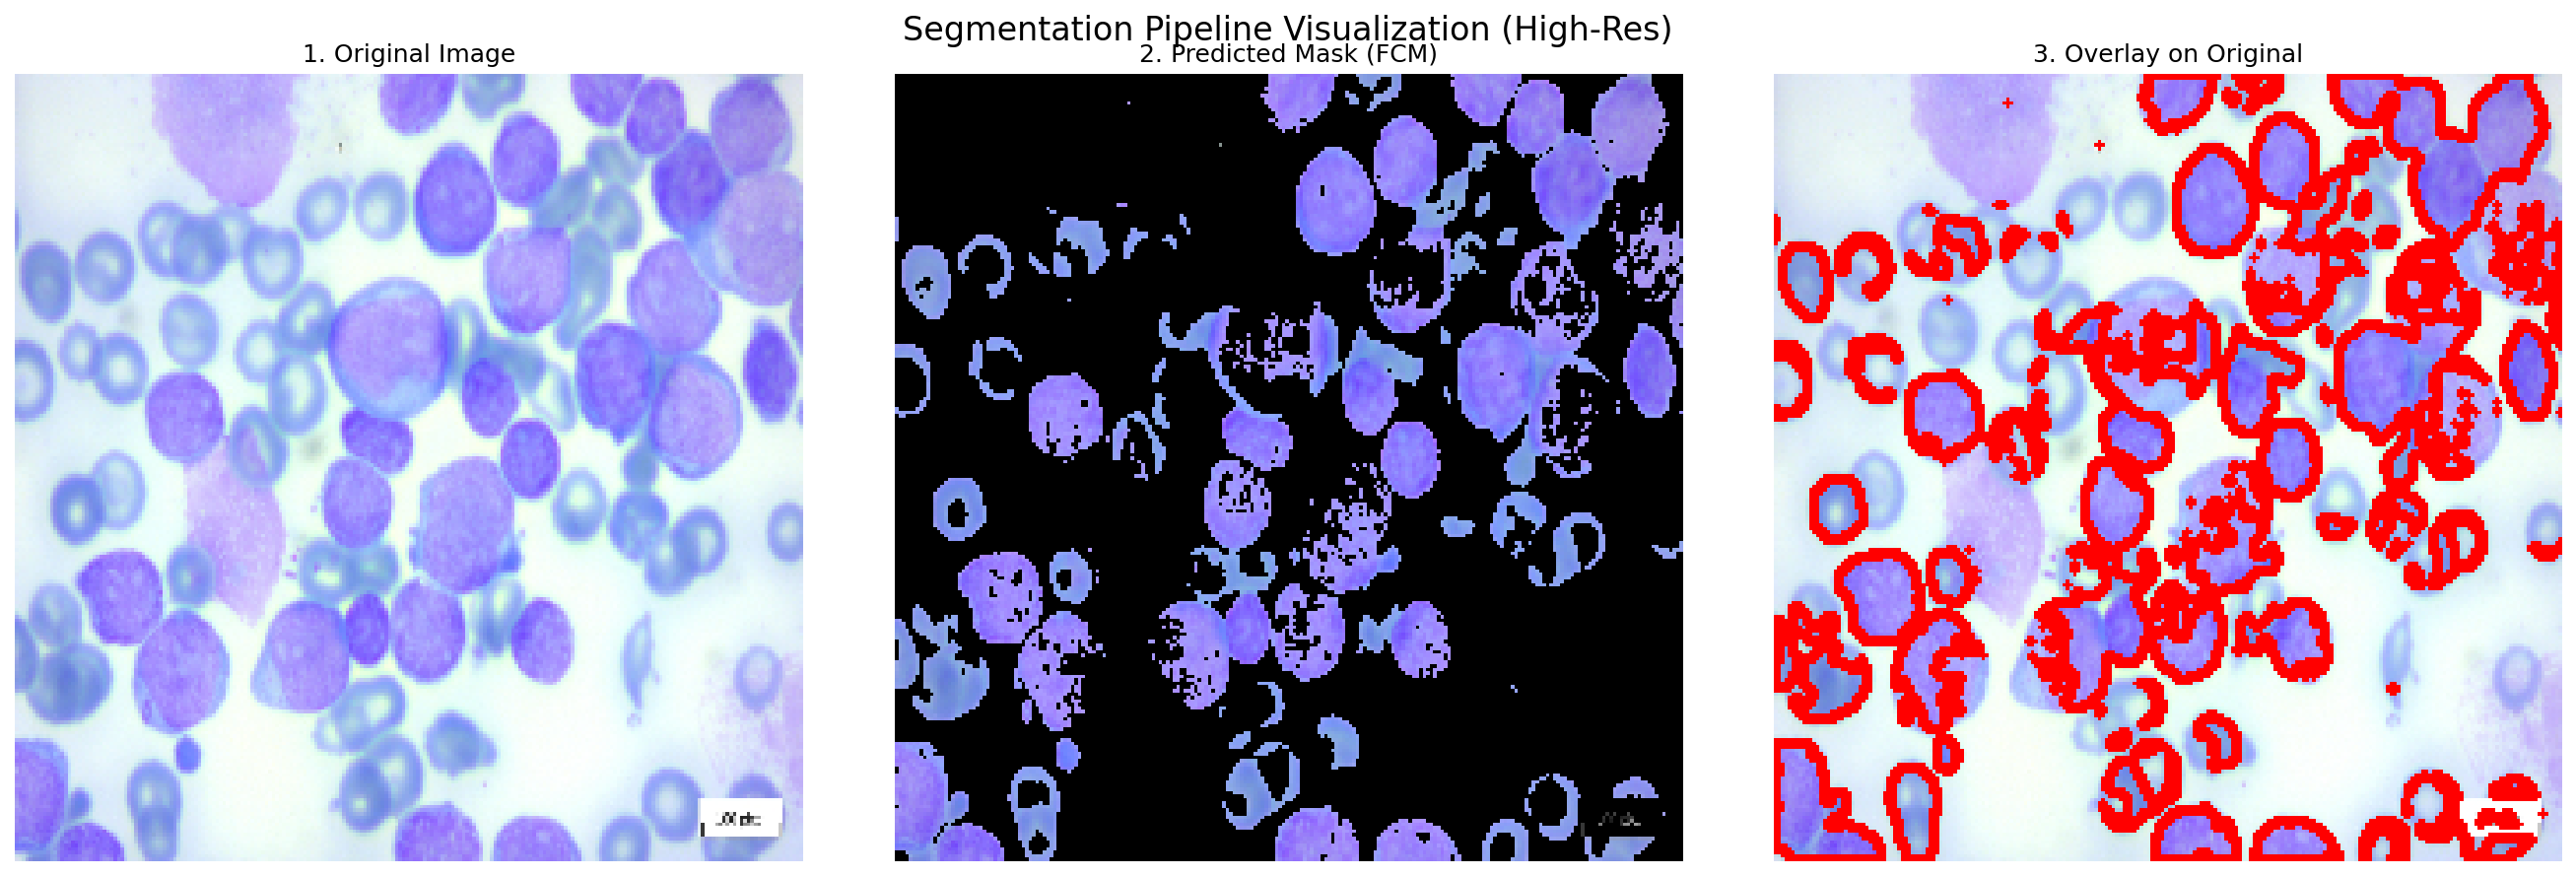

In [5]:
# --- Visualize a sample from the test set ---
print("--- Visualizing Simplified Segmentation Pipeline (High-Res) ---")
visualize_segmentation_pipeline(X_test_paths[10], IMG_SIZE, N_CLUSTERS)
# Select 5 random indices from the test set
sample_indices = np.random.choice(len(X_test_paths), 5, replace=False)

print("--- Displaying Segmentation Pipeline for 5 Random Sample Images ---")

for i, index in enumerate(sample_indices):
    print(f"\n--- Sample Image {i+1} ---")
    image_path = X_test_paths[index]
    visualize_segmentation_pipeline(image_path, IMG_SIZE, N_CLUSTERS)

In [6]:
def create_feature_extractor(img_size):
    base_model = EfficientNetB4(
        weights='imagenet',
        include_top=False,
        input_shape=(img_size, img_size, 3),
        pooling='avg'
    )
    return base_model

feature_extractor = create_feature_extractor(IMG_SIZE)

I0000 00:00:1759413746.888825      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759413746.889480      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
# --- Cell 7 (Corrected) ---

# 1. First, ensure Graphviz is installed in the current session
!apt-get install -y graphviz

# 2. Now, plot the model using the simplified diagram option
print("Attempting to visualize model architecture...")
try:
    plot_model(
        feature_extractor,
        to_file='efficientnetb4_architecture.png',
        show_shapes=True,
        expand_nested=True  # Simplifies the diagram for large models
    )
    print("Model architecture saved to 'efficientnetb4_architecture.png'")
    display(Image(filename='efficientnetb4_architecture.png'))
except Exception as e:
    print(f"\nPlotting failed. Error: {e}")
    print("\nDisplaying text-based summary as a fallback:")
    feature_extractor.summary()




graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
Attempting to visualize model architecture...
"dot" with args ['-Tpng', '/tmp/tmpuch8tfnr/tmpr4zok7c2'] returned code: -6

stdout, stderr:
 b''
b"newtrap: Trapezoid-table overflow 9541\ndot: trapezoid.c:84: newtrap: Assertion `0' failed.\n"


Plotting failed. Error: "dot" with args ['-Tpng', '/tmp/tmpuch8tfnr/tmpr4zok7c2'] returned code: -6

Displaying text-based summary as a fallback:


Model: "efficientnetb4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 17,673,823 (67.42 MB)

 Trainable params: 17,548,616 (66.94 MB)

 Non-trainable params: 125,207 (489.09 KB)

In [8]:
def extract_features_and_save(image_paths, model, img_size, n_clusters, output_dir_base, set_name):
    """Extracts features and saves the segmented image used for extraction."""
    features = []
    output_dir = os.path.join(output_dir_base, set_name)
    
    for path in tqdm(image_paths, desc=f"Extracting Features & Saving Slices for {set_name}"):
        segmented_img = segment_image_fcm(path, img_size, n_clusters)
        
        # Save the segmented image (convert back to BGR for cv2)
        filename = os.path.basename(path)
        save_path = os.path.join(output_dir, filename)
        cv2.imwrite(save_path, cv2.cvtColor(segmented_img, cv2.COLOR_RGB2BGR))
        
        # Preprocess and extract features
        img_array = tf.keras.applications.efficientnet.preprocess_input(segmented_img)
        img_array = np.expand_dims(img_array, axis=0)
        current_features = model.predict(img_array, verbose=0)
        features.append(current_features.flatten())
        
    return np.array(features)

# --- Extract features for both training and testing sets ---
X_train_features = extract_features_and_save(X_train_paths, feature_extractor, IMG_SIZE, N_CLUSTERS, SEG_OUTPUT_DIR, 'train')
X_test_features = extract_features_and_save(X_test_paths, feature_extractor, IMG_SIZE, N_CLUSTERS, SEG_OUTPUT_DIR, 'test')

print(f"\nShape of training features: {X_train_features.shape}")
print(f"Shape of testing features: {X_test_features.shape}")

Extracting Features & Saving Slices for train:   0%|          | 0/2593 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1759413763.276727      78 service.cc:148] XLA service 0x7ef9ec003c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759413763.278890      78 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759413763.278911      78 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759413764.674067      78 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1759413770.709281      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Extracting Features & Saving Slices for test: 100%|██████████| 649/649 [09:55<00:00,  1.09it/s]


Shape of training features: (2593, 1792)
Shape of testing features: (649, 1792)


Training XGBoost model on GPU...


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [14:51:55] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  self.starting_round = model.num_boosted_rounds()


Training complete.


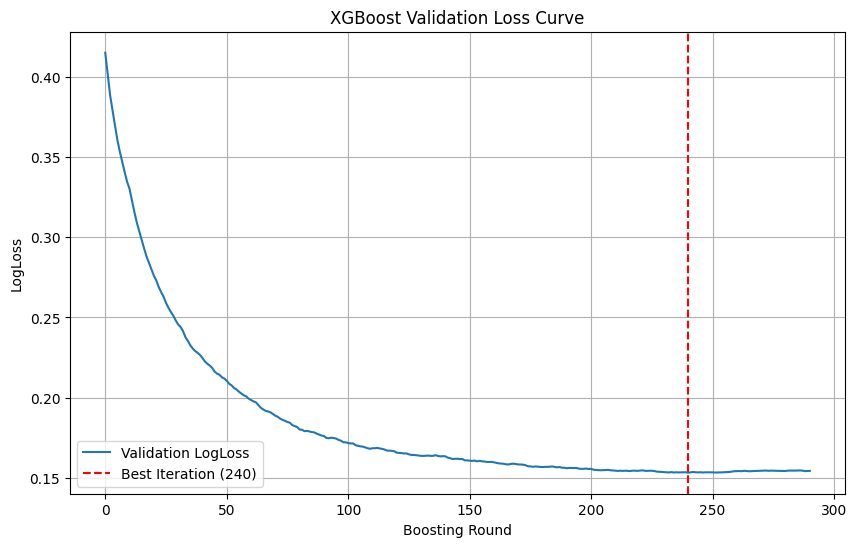

In [9]:
# Split training data for validation during XGBoost training
X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train_features, y_train, test_size=0.2, random_state=42, stratify=y_train)

# Convert data into DMatrix for XGBoost
dtrain = xgb.DMatrix(X_train_new, label=y_train_new)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test_features, label=y_test)

# Define model parameters with GPU enabled
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'max_depth': 4,
    'learning_rate': 0.05,
    'random_state': 42,
    'tree_method': 'gpu_hist'  # Enable GPU for training
}

# Dictionary to store evaluation results
evals_result = {}

print("Training XGBoost model on GPU...")
bst_model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=False,
    evals_result=evals_result  # Capture history
)
print("Training complete.")

# --- Plotting Validation Curve ---
plt.figure(figsize=(10, 6))
plt.plot(evals_result['validation']['logloss'], label='Validation LogLoss')
plt.axvline(x=bst_model.best_iteration, color='r', linestyle='--', label=f'Best Iteration ({bst_model.best_iteration})')
plt.title('XGBoost Validation Loss Curve')
plt.xlabel('Boosting Round')
plt.ylabel('LogLoss')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
def calculate_all_metrics(y_true, y_pred, target_names=['Benign', 'Malignant']):
    """Calculates and prints a comprehensive set of classification metrics."""
    print("--- Detailed Classification Metrics ---")
    
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1, 1]  # Malignant correctly identified
    FP = cm[0, 1]  # Benign incorrectly identified as Malignant
    FN = cm[1, 0]  # Malignant incorrectly identified as Benign
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    dice_score = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
    jaccard_iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    
    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Precision (Malignant): {precision:.4f}")
    print(f"Recall/Sensitivity (Malignant): {recall:.4f}")
    print(f"F1-Score (Malignant): {f1_score:.4f}")
    print(f"Dice Score (Malignant): {dice_score:.4f}")
    print(f"Jaccard Index / IoU (Malignant): {jaccard_iou:.4f}\n")
    
    print("--- Full Classification Report ---")
    print(classification_report(y_true, y_pred, target_names=target_names))

In [11]:
# Make predictions on the test set
y_pred_probs = bst_model.predict(dtest, iteration_range=(0, bst_model.best_iteration))
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Calculate and display all metrics for the test set
calculate_all_metrics(y_test, y_pred_labels)

--- Detailed Classification Metrics ---
Overall Accuracy: 0.9553
Precision (Malignant): 0.9544
Recall/Sensitivity (Malignant): 0.9945
F1-Score (Malignant): 0.9740
Dice Score (Malignant): 0.9740
Jaccard Index / IoU (Malignant): 0.9494

--- Full Classification Report ---
              precision    recall  f1-score   support

      Benign       0.96      0.75      0.84       102
   Malignant       0.95      0.99      0.97       547

    accuracy                           0.96       649
   macro avg       0.96      0.87      0.91       649
weighted avg       0.96      0.96      0.95       649



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:729: UserWarning: [14:52:00] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  return func(**kwargs)


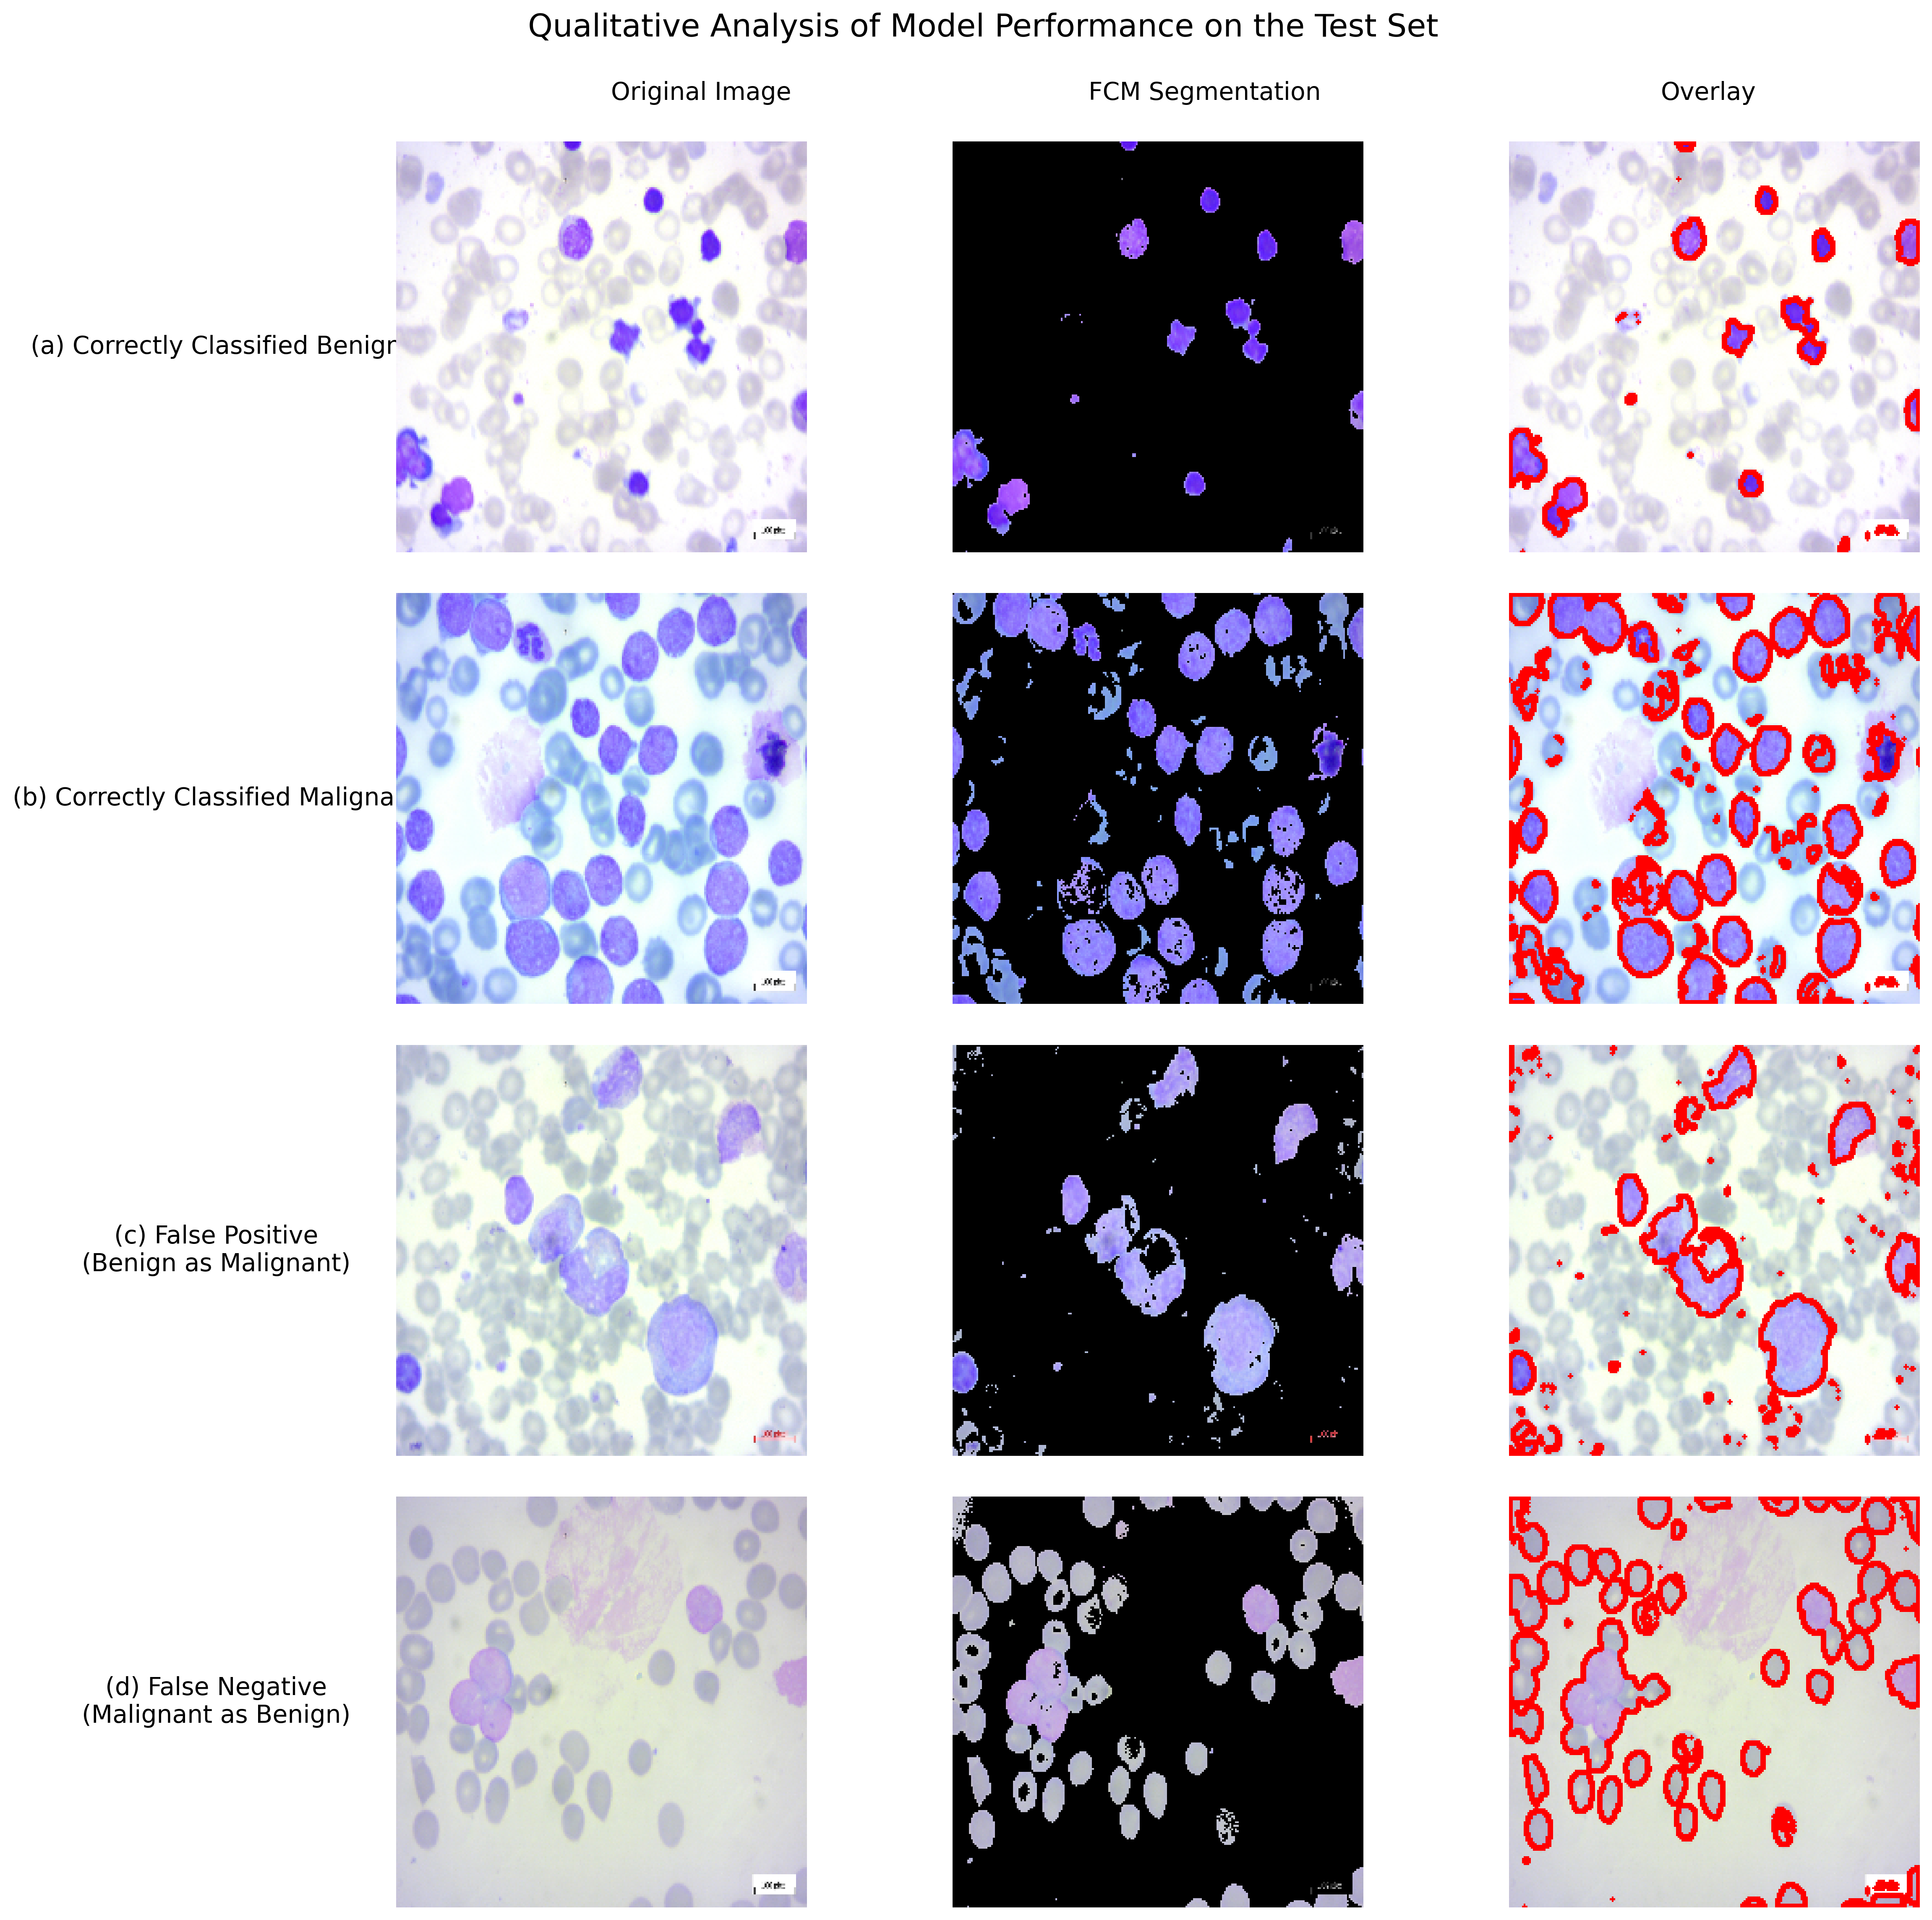

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import skfuzzy as fuzz
from matplotlib.gridspec import GridSpec

# 1. Ensure your original, working segmentation function is defined
def segment_image_fcm(image_path, img_size, n_clusters):
    """Performs the actual Fuzzy C-Means segmentation."""
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    
    pixel_values = img.reshape((-1, 3)).astype(np.float32)
    
    cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
        pixel_values.T, n_clusters, 2, error=0.005, maxiter=1000, init=None
    )
    
    cluster_membership = np.argmax(u, axis=0)
    
    counts = np.bincount(cluster_membership)
    target_cluster = np.argmin(counts[np.nonzero(counts)]) if len(counts) > 1 else 0
    
    segmented_pixels = np.zeros_like(pixel_values, dtype=np.uint8)
    segmented_pixels[cluster_membership == target_cluster] = pixel_values[cluster_membership == target_cluster].astype(np.uint8)
    
    return segmented_pixels.reshape(img.shape)

# 2. HELPER FUNCTION TO GENERATE PANELS
def visualize_for_paper(image_path, img_size=224, n_clusters=3):
    """Generates the three panels (Original, Segmented, Overlay) for a single sample."""
    original_img = cv2.resize(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB), (img_size, img_size))
    predicted_segmented_img = segment_image_fcm(image_path, img_size, n_clusters)
    
    gray_mask = cv2.cvtColor(predicted_segmented_img, cv2.COLOR_RGB2GRAY)
    _, binary_mask = cv2.threshold(gray_mask, 1, 255, cv2.THRESH_BINARY)
    overlay = original_img.copy()
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)
    
    return original_img, predicted_segmented_img, overlay

# 3. MAIN PLOTTING CODE WITH CUSTOM LAYOUT
# Assume y_test and y_pred_labels are already defined
true_positives = np.where((y_test == 1) & (y_pred_labels == 1))[0]
true_negatives = np.where((y_test == 0) & (y_pred_labels == 0))[0]
false_positives = np.where((y_test == 0) & (y_pred_labels == 1))[0]
false_negatives = np.where((y_test == 1) & (y_pred_labels == 0))[0]

idx_tn = true_negatives[0] if len(true_negatives) > 0 else None
idx_tp = true_positives[0] if len(true_positives) > 0 else None
idx_fp = false_positives[0] if len(false_positives) > 0 else None
idx_fn = false_negatives[0] if len(false_negatives) > 0 else None

samples_to_plot = {
    "(a) Correctly Classified Benign": idx_tn,
    "(b) Correctly Classified Malignant": idx_tp,
    "(c) False Positive\n(Benign as Malignant)": idx_fp,
    "(d) False Negative\n(Malignant as Benign)": idx_fn
}

# --- Create figure with custom layout ---
fig = plt.figure(figsize=(16, 16), dpi=300)
# Use GridSpec to define a 4x4 grid, with the first column being narrower
gs = GridSpec(4, 4, figure=fig, width_ratios=[0.25, 0.75, 0.75, 0.75])

fig.suptitle('Qualitative Analysis of Model Performance on the Test Set', fontsize=18, y=0.95)

col_titles = ['Original Image', 'FCM Segmentation', 'Overlay']
# Add column titles manually
fig.text(0.36, 0.91, col_titles[0], ha='center', va='center', fontsize=14)
fig.text(0.61, 0.91, col_titles[1], ha='center', va='center', fontsize=14)
fig.text(0.86, 0.91, col_titles[2], ha='center', va='center', fontsize=14)

for i, (title, index) in enumerate(samples_to_plot.items()):
    # Add row label in the first (narrow) column
    ax_label = fig.add_subplot(gs[i, 0])
    ax_label.text(0.5, 0.5, title, ha='center', va='center', fontsize=14, wrap=True)
    ax_label.axis('off')

    # Add the three image plots in the remaining columns
    if index is not None:
        path = X_test_paths[index]
        orig, seg, over = visualize_for_paper(path)
        
        ax1 = fig.add_subplot(gs[i, 1])
        ax1.imshow(orig)
        ax1.axis('off')

        ax2 = fig.add_subplot(gs[i, 2])
        ax2.imshow(seg)
        ax2.axis('off')
        
        ax3 = fig.add_subplot(gs[i, 3])
        ax3.imshow(over)
        ax3.axis('off')
    else:
        # If no example is found, add placeholder text
        for j in range(1, 4):
            ax = fig.add_subplot(gs[i, j])
            ax.text(0.5, 0.5, 'No example found\nin test set', ha='center', va='center', fontsize=12)
            ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig('qualitative_analysis.png', bbox_inches='tight')
plt.show()
